In [1]:
%load_ext autoreload
%autoreload 2
!hostname
!pwd
import os, sys
print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

slurm0-gpu1nodeset-0
/home/akarsh_sakana_ai/alife-repr/src
/home/akarsh_sakana_ai/.conda/envs/asal/bin/python


In [38]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

In [4]:
import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

In [5]:
import experiment_utils
from main import *

In [6]:
import main
argd = main.Args()

argd.n_iters = 50000
argd.log_every = 1000

args_all = []
for seed in range(5):
    for dt in [1, 2, 4, 8, 16, 32, 64]:
        args = copy.deepcopy(argd)
        args.seed = seed
        args.data.dt = dt
        args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/run_0/dt={dt}_{seed}"
        args_all.append(args)
        print(args)
experiment_utils.create_commands(args_all, prefix="python main.py", out_file="science_scripts/main.sh");

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0', n_iters=50000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=1))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=2_0', n_iters=50000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=2))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=4_0', n_iters=50000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, 

In [7]:
import linear_probe
argd = linear_probe.LinearProbeArgs()

argd.n_iters = 10000
argd.log_every = 1000
argd.opt.weight_decay = 0.

lp_args_all = []
for args in args_all:
    lp_args = copy.deepcopy(argd)
    lp_args.seed = args.seed
    lp_args.load_dir = args.save_dir
    lp_args.save_dir = f"{args.save_dir}_lp"
    lp_args_all.append(lp_args)
    print(lp_args)
experiment_utils.create_commands(lp_args_all, prefix="python linear_probe.py", out_file="science_scripts/linear_probe.sh");

LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0_lp', n_iters=10000, log_every=1000, opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0))
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=2_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=2_0_lp', n_iters=10000, log_every=1000, opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0))
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=4_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=4_0_lp', n_iters=10000, log_every=1000, opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0))
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=8_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=8_0_lp', n_ite

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0', n_iters=10000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=1))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=2_0', n_iters=10000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=2))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=4_0', n_iters=10000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, 

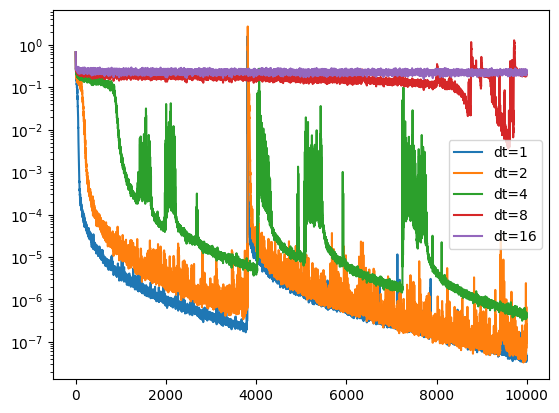

In [40]:
import util

for args in args_all[:5]:
    print(args)
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    plt.plot(loss_history, label=f"dt={args.data.dt}")
plt.legend()
plt.yscale('log')
plt.show()

LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=1_0_lp', n_iters=10000, log_every=1000, opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0))
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=2_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=2_0_lp', n_iters=10000, log_every=1000, opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0))
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=4_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=4_0_lp', n_iters=10000, log_every=1000, opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0))
LinearProbeArgs(seed=0, load_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=8_0', save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_0/dt=8_0_lp',

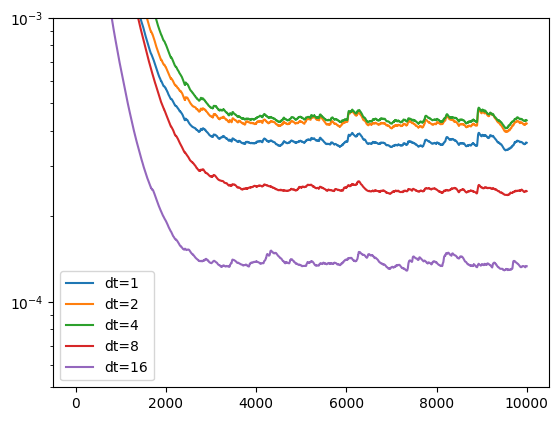

In [48]:
import pandas as pd

df = []

for args, lp_args in zip(args_all, lp_args_all):
    print(lp_args)
    losses = util.load_pkl(lp_args.save_dir, "loss_history")
    losses = np.array(losses)
    plt.plot(pd.DataFrame(losses).ewm(span=1000).mean(), label=f"dt={args.data.dt}")
    # plt.plot(losses, label=f"dt={args.data.dt}")
plt.legend()
plt.yscale('log')
plt.ylim(5e-5, 1e-3)
plt.show()

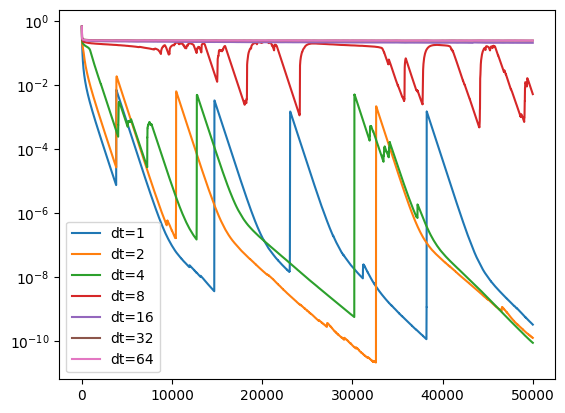

In [65]:
import util

for args in args_all[:7]:
    losses = util.load_pkl(args.save_dir, "loss_history")
    losses = np.array(losses)
    plt.plot(pd.DataFrame(losses).ewm(span=1000).mean(), label=f"dt={args.data.dt}")
plt.legend()
plt.yscale('log')
plt.show()

In [29]:
df = []
for args, lp_args in zip(args_all, lp_args_all):
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss = np.mean(loss_history[-5000:])
    loss_history = util.load_pkl(lp_args.save_dir, "loss_history")
    lp_loss = np.mean(loss_history[-1000:])
    dfi = dict(seed=args.seed, dt=args.data.dt, loss=loss, lp_loss=lp_loss)
    df.append(dfi)

df = pd.DataFrame(df)

In [62]:
df

,seed,dt,loss,lp_loss
0,0,1,1.647889e-09,0.000339
1,0,2,5.359744e-10,0.000529
2,0,4,4.402124e-10,0.000522
3,0,8,2.936208e-02,0.000335
4,0,16,2.114381e-01,0.000124
5,0,32,2.482911e-01,0.000136
6,0,64,2.486065e-01,0.000099
7,1,1,7.490584e-13,0.000546
8,1,2,6.237204e-10,0.000510
9,1,4,1.074746e-04,0.000324


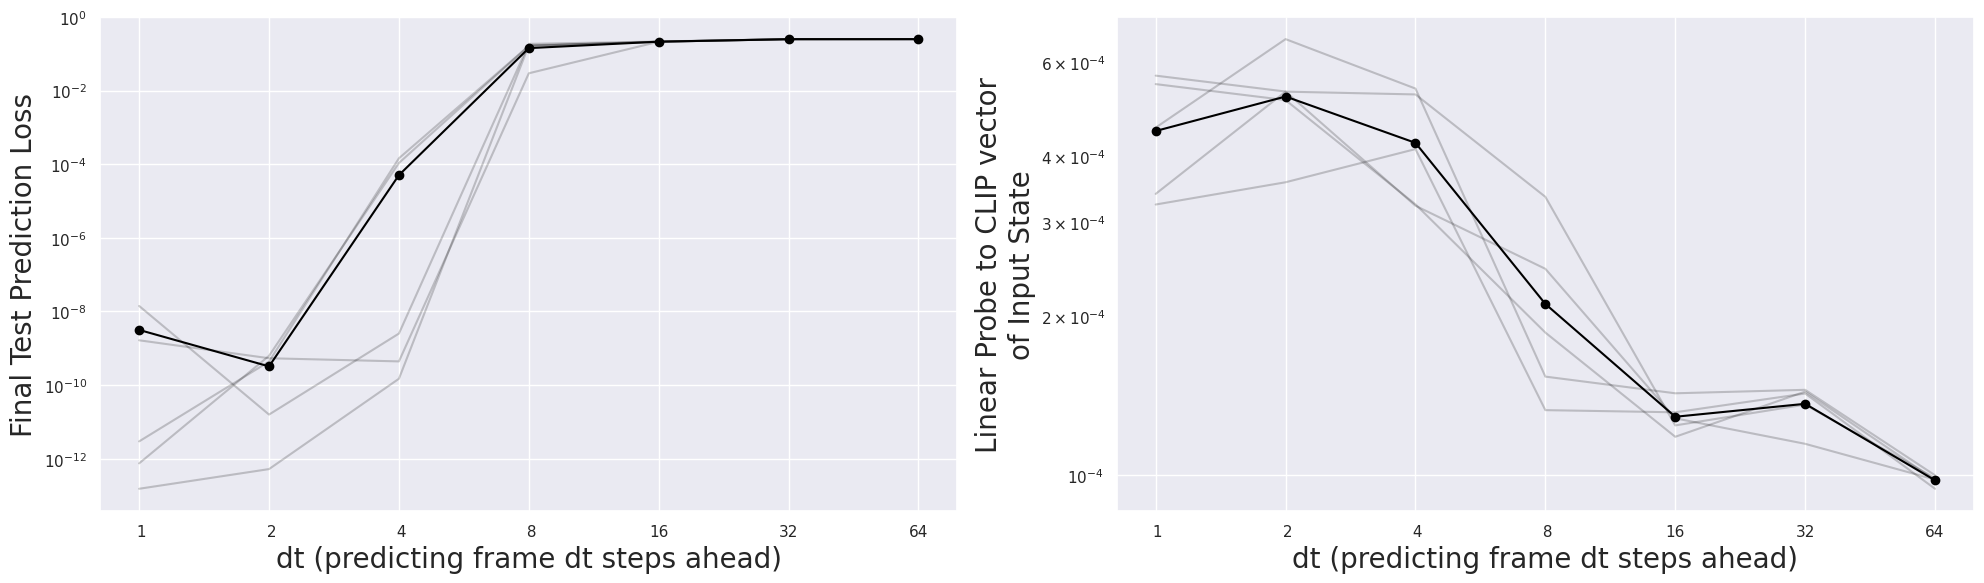

In [135]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)

for seed in range(5):
    a = df[df.seed==seed]
    plt.plot(a.dt, a.loss, c='black', alpha=0.2)
a = df.groupby("dt").mean()
plt.plot(a.index, a.loss, c='black', alpha=1)
plt.scatter(a.index, a.loss, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Final Test Prediction Loss", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])

plt.subplot(1, 2, 2)

for seed in range(5):
    a = df[df.seed==seed]
    plt.plot(a.dt, a.lp_loss, c='black', alpha=0.2)
a = df.groupby("dt").mean()
plt.plot(a.index, a.lp_loss, c='black', alpha=1)
plt.scatter(a.index, a.lp_loss, c='black', alpha=1)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Linear Probe to CLIP vector\nof Input State", fontsize=20)
plt.xlabel("dt (predicting frame dt steps ahead)", fontsize=20)
plt.xticks(a.index, [f"{x:2d}" for x in a.index])

plt.tight_layout()
plt.show()

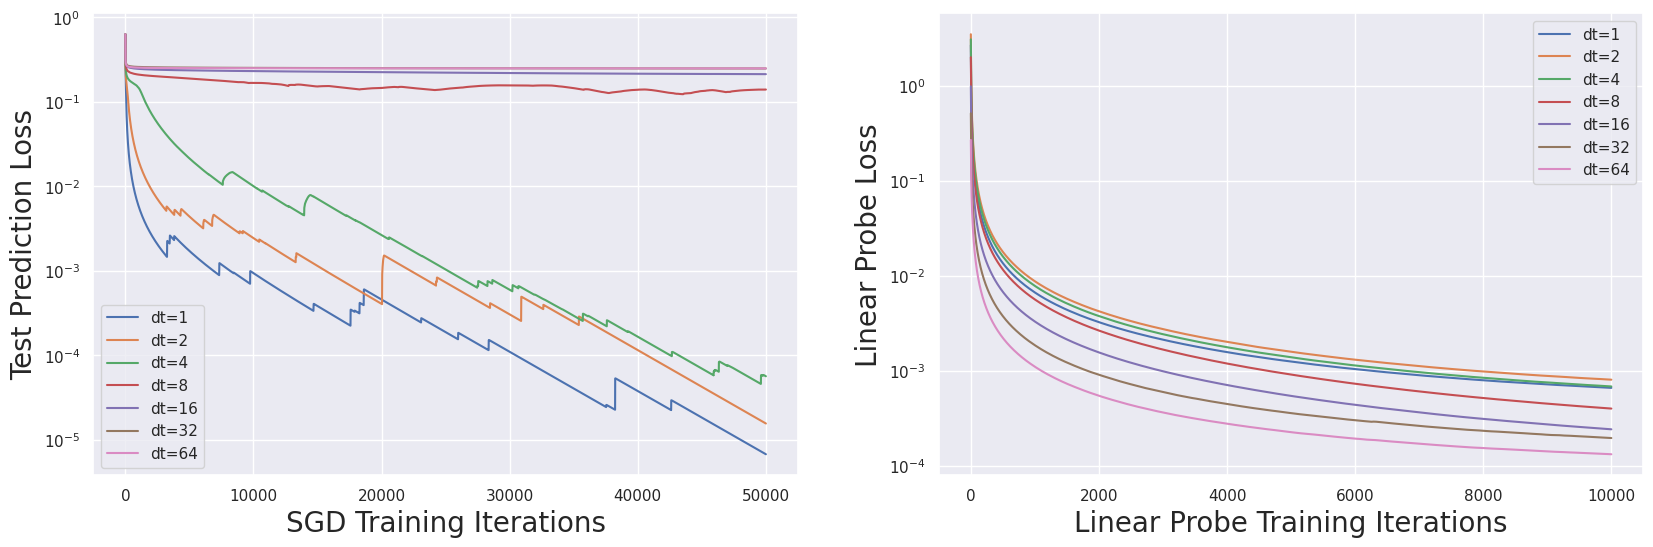

In [137]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
for dt in df.dt.unique():
    data = []
    for args, lp_args in zip(args_all, lp_args_all):
        if args.data.dt != dt:
            continue
        data.append(np.array(util.load_pkl(args.save_dir, "loss_history")))
    data = np.array(data)
    mean, std = data.mean(axis=0), data.std(axis=0)
    mean = pd.DataFrame(mean).ewm(span=10000).mean()
    plt.plot(mean, label=f'dt={dt}')
plt.yscale('log')
plt.legend()
plt.ylabel('Test Prediction Loss', fontsize=20)
plt.xlabel('SGD Training Iterations', fontsize=20)

plt.subplot(1, 2, 2)
for dt in df.dt.unique():
    data = []
    for args, lp_args in zip(args_all, lp_args_all):
        if args.data.dt != dt:
            continue
        data.append(np.array(util.load_pkl(lp_args.save_dir, "loss_history")))
    data = np.array(data)
    mean, std = data.mean(axis=0), data.std(axis=0)
    mean = pd.DataFrame(mean).ewm(span=10000).mean()
    plt.plot(mean, label=f'dt={dt}')
plt.yscale('log')
plt.legend()
plt.ylabel('Linear Probe Loss', fontsize=20)
plt.xlabel('Linear Probe Training Iterations', fontsize=20)

plt.show()